## QML-FAST: 3-field example (noise-bias-subtracted)

Full QML pipeline on 3 correlated Gaussian fields at nside=16:
1. Build pixel covariance (signal + white pixel noise), mask, mode deprojection
2. Compute Fisher matrix with `getF`
3. Compute noise bias $b_A = \tfrac12\mathrm{Tr}(M\,P_A\,M\,\mathbb{N})$
4. Run MC sims (signal via `synalm` + pixel noise) and obtain noise-subtracted QML estimates
5. Compare analytic $F^{-1}$ and empirical error bars — should agree since $C_{\rm true} = C_{\rm fid}$

In [19]:
import sys
sys.path.append('./')
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import opt_einsum as oe
import scipy as sp
from tqdm import tqdm

from utilities import *
from qmlfast import *

### 1. Simulation setup

In [20]:
nside = 16
lmax  = 3*nside - 1
n_ell = 3*nside
ell   = np.arange(n_ell).astype(float)

S_aa = (ell+1)**(-2)
S_bb = 3*(ell+1)**(-2)
S_cc = 5*(ell+1)**(-2)
S_ab = np.sqrt(S_aa*S_bb)
S_ca = np.sqrt(S_aa*S_cc)
S_bc = np.sqrt(S_bb*S_cc)

N_a, N_b, N_c = 5e-2, 5e-2, 1e-2
A_ab, A_ca, A_bc = 0.3, 0.5, 0.5

# Signal cross-spectra (with correlation amplitudes)
S_ab_fid = A_ab * S_ab
S_ca_fid = A_ca * S_ca
S_bc_fid = A_bc * S_bc

# Total spectra (for reference / old-style sims)
C_aa = S_aa + N_a
C_bb = S_bb + N_b
C_cc = S_cc + N_c
C_ab = A_ab * S_ab
C_ca = A_ca * S_ca
C_bc = A_bc * S_bc

Nf = 3

Sky fraction: 0.65


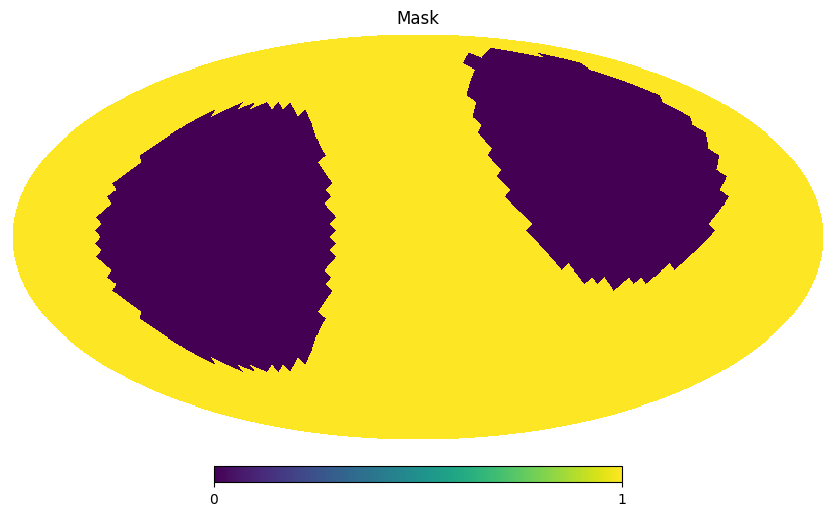

In [21]:
# Mask
vec = hp.ang2vec(np.pi / 2, np.pi/2)
ipix_disc = hp.query_disc(nside=nside, vec=vec, radius=np.radians(51))
vec1 = hp.ang2vec(np.pi / 3, 3*np.pi/2)
ipix_disc1 = hp.query_disc(nside=nside, vec=vec1, radius=np.radians(47))

mask = np.ones(hp.nside2npix(nside))
mask[ipix_disc] = 0.
mask[ipix_disc1] = 0.
hp.mollview(mask, title='Mask')
print(f'Sky fraction: {mask.mean():.2f}')

In [22]:
def get_pix_cov_block(cl, Pl_ij, lmin, lmax):
    return oe.contract('ijk,i->jk', Pl_ij[lmin:lmax], cl[lmin:lmax])

theta, phi = theta_phi(nside)
theta = theta[mask==1]
phi = phi[mask==1]
Pl_ij = get_Pl_ij(theta, phi, nside, lmax=lmax)

Np = len(theta)
omega_pix = 4 * np.pi / hp.nside2npix(nside)

# Pixel-space noise covariance (uncorrelated between fields)
N_pix = np.zeros([Nf*Np, Nf*Np])
N_pix[block_np(0, 0, Np)] = np.eye(Np) * N_a / omega_pix
N_pix[block_np(1, 1, Np)] = np.eye(Np) * N_b / omega_pix
N_pix[block_np(2, 2, Np)] = np.eye(Np) * N_c / omega_pix
N_diag = np.array([N_a, N_b, N_c])

# Signal (band-limited) + white pixel noise
large_cov = np.zeros([Nf*Np, Nf*Np])
large_cov[block_np(0, 0, Np)] = get_pix_cov_block(S_aa,     Pl_ij, 0, n_ell) + N_pix[block_np(0, 0, Np)]
large_cov[block_np(0, 1, Np)] = get_pix_cov_block(S_ab_fid, Pl_ij, 0, n_ell)
large_cov[block_np(0, 2, Np)] = get_pix_cov_block(S_ca_fid, Pl_ij, 0, n_ell)
large_cov[block_np(1, 0, Np)] = large_cov[block_np(0, 1, Np)].T
large_cov[block_np(1, 1, Np)] = get_pix_cov_block(S_bb,     Pl_ij, 0, n_ell) + N_pix[block_np(1, 1, Np)]
large_cov[block_np(1, 2, Np)] = get_pix_cov_block(S_bc_fid, Pl_ij, 0, n_ell)
large_cov[block_np(2, 0, Np)] = large_cov[block_np(0, 2, Np)].T
large_cov[block_np(2, 1, Np)] = large_cov[block_np(1, 2, Np)].T
large_cov[block_np(2, 2, Np)] = get_pix_cov_block(S_cc,     Pl_ij, 0, n_ell) + N_pix[block_np(2, 2, Np)]

print(f'Np = {Np}, cond(C) = {np.linalg.cond(large_cov):.2e}')

Np = 2008, cond(C) = 4.47e+02


### 2. Mode deprojection ($\ell < \ell_{\min}$)

In [23]:
ell0 = 4
Z, pi = construct_Z_and_pi(theta, phi, ell0=ell0, lmax=lmax)

for i in range(Nf):
    for j in range(Nf):
        block = large_cov[block_np(i,j,Np)]
        large_cov[block_np(i,j,Np)] = pi @ block @ pi.T

eta = 1e-1
ZZT_block = sp.linalg.block_diag(*[Z @ Z.T]*Nf)
M = np.linalg.inv(large_cov + eta * ZZT_block)
for i in range(Nf):
    for j in range(Nf):
        block = M[block_np(i,j,Np)]
        M[block_np(i,j,Np)] = pi @ block @ pi.T

### 3. Fisher matrix

In [24]:
F_idx = np.array([(i, j, l) for l in range(n_ell)
                  for i in range(Nf) for j in range(i, Nf)])
C_map = np.ones([Nf, Nf])
n_pairs = Nf * (Nf + 1) // 2  # 6

Y_r_all = sph_harm_y_real_all(n_ell, theta, phi)
F = getF(Y_r_all, M, F_idx, Nf, Np, C_map)
print(f'F shape: {F.shape}')

# Sanity: deprojected modes should have F ~ 0
null_block = F[np.ix_(F_idx[:,2]<ell0, F_idx[:,2]<ell0)]
print(f'F[ell<{ell0}] max = {np.max(np.abs(null_block)):.1e}  (should be ~0)')

VCinvV: 100%|█████████████████████████████████████| 6/6 [00:00<00:00, 19.50it/s]

F shape: (288, 288)
F[ell<4] max = 1.9e-29  (should be ~0)


### 4. Noise bias

$b_A = \tfrac12\,\mathrm{Tr}(M\,P_A\,M\,\mathbb{N})$, with prefactor $\tfrac12$
for auto pairs and $1$ for cross pairs (matching the `get_y` convention).

In [25]:
MNM = M @ N_pix @ M

noise_bias = np.zeros(len(F_idx))
for a, (f1, f2, l) in enumerate(F_idx):
    MNM_block = MNM[block_np(f1, f2, Np)]
    prefactor = 0.5 if f1 == f2 else 1.0
    noise_bias[a] = prefactor * np.einsum('ij,ji->', MNM_block, Pl_ij[l])

print(f'noise_bias range: [{noise_bias.min():.4e}, {noise_bias.max():.4e}]')

noise_bias range: [-1.6119e+02, 2.1237e+03]


### 5. Run simulations (signal + pixel noise, bias-subtracted)

In [26]:
V_packed, offsets, ranks = pack_sph_harm(Y_r_all)
rng = np.random.default_rng(42)
n_sims = 2500

ys = []
for i in tqdm(range(n_sims)):
    # Band-limited signal (correlated across fields)
    alm_a, alm_b, alm_c = hp.synalm(
        [S_aa, S_ab_fid, S_ca_fid, S_bb, S_bc_fid, S_cc], lmax=lmax)
    sig_a = hp.alm2map(alm_a, nside)[mask==1]
    sig_b = hp.alm2map(alm_b, nside)[mask==1]
    sig_c = hp.alm2map(alm_c, nside)[mask==1]
    # Pixel-space white noise (uncorrelated between fields)
    noise_a = rng.normal(0, np.sqrt(N_a / omega_pix), Np)
    noise_b = rng.normal(0, np.sqrt(N_b / omega_pix), Np)
    noise_c = rng.normal(0, np.sqrt(N_c / omega_pix), Np)
    x = np.stack([sig_a + noise_a, sig_b + noise_b, sig_c + noise_c])
    y = get_y_packed(x, V_packed, offsets, ranks, M, F_idx, Nf, Np)
    ys.append(y - noise_bias)

ys = np.array(ys)
print(f'ys shape: {ys.shape}')

100%|███████████████████████████████████████| 2500/2500 [04:34<00:00,  9.10it/s]

ys shape: (2500, 288)


In [27]:
# Remove deprojected modes and invert
active = F_idx[:, 2] >= ell0
ys_active = ys[:, active]
F_active = F[np.ix_(active, active)]
invF = np.linalg.inv(F_active)
f_idx = F_idx[active]

es = ys_active @ invF.T
e_mean = es.mean(axis=0)
err_analytic = invF
err_empirical = np.cov(es, rowvar=False, ddof=1)


In [28]:
ys.shape

(2500, 288)

### 6. Plot auto-power spectra (noise-subtracted → targets $S$, not $C$)

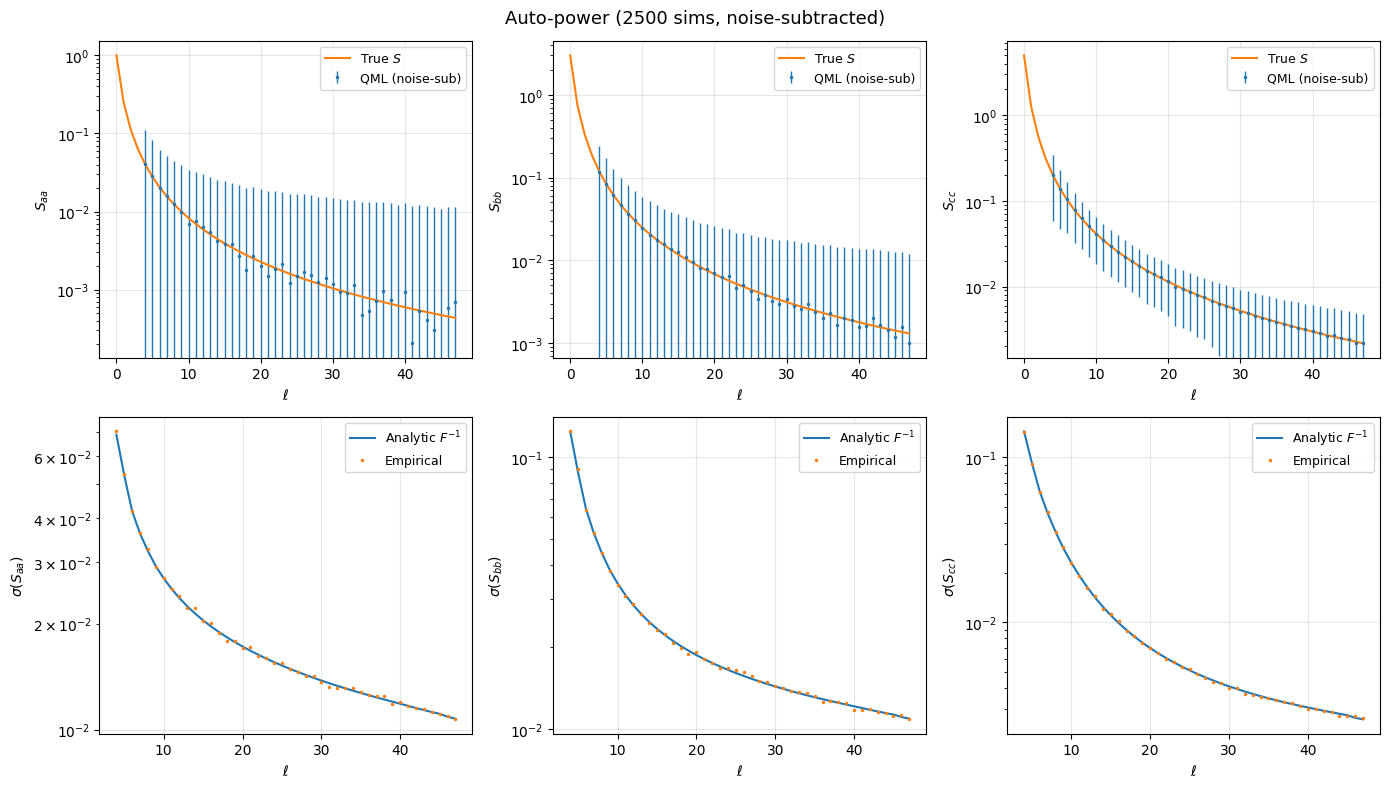

In [29]:
fig, axs = plt.subplots(2, 3, figsize=(14, 8))

spectra = [
    ((0,0), S_aa, r'$S_{aa}$'),
    ((1,1), S_bb, r'$S_{bb}$'),
    ((2,2), S_cc, r'$S_{cc}$'),
]

ells_plot = np.arange(ell0, n_ell)

for col, ((fi, fj), S_true, label) in enumerate(spectra):
    idx = (f_idx[:,0]==fi) & (f_idx[:,1]==fj)

    axs[0, col].errorbar(ells_plot, e_mean[idx],
                         yerr=np.sqrt(np.diag(err_analytic)[idx]),
                         fmt='.', ms=3, lw=1, label='QML (noise-sub)')
    axs[0, col].semilogy(ell, S_true, '-', lw=1.5, label='True $S$')
    axs[0, col].set_xlabel(r'$\ell$')
    axs[0, col].set_ylabel(label)
    axs[0, col].legend(fontsize=9)
    axs[0, col].grid(alpha=0.3)

    sig_an = np.sqrt(np.diag(err_analytic)[idx])
    sig_em = np.sqrt(np.diag(err_empirical)[idx])
    axs[1, col].semilogy(ells_plot, sig_an, '-', lw=1.5, label='Analytic $F^{-1}$')
    axs[1, col].semilogy(ells_plot, sig_em, '.', ms=3, label='Empirical')
    axs[1, col].set_xlabel(r'$\ell$')
    axs[1, col].set_ylabel(f'$\sigma$({label})')
    axs[1, col].legend(fontsize=9)
    axs[1, col].grid(alpha=0.3)

plt.suptitle(f'Auto-power ({n_sims} sims, noise-subtracted)', fontsize=13)
plt.tight_layout()
plt.show()

### 7. Plot cross-power spectra

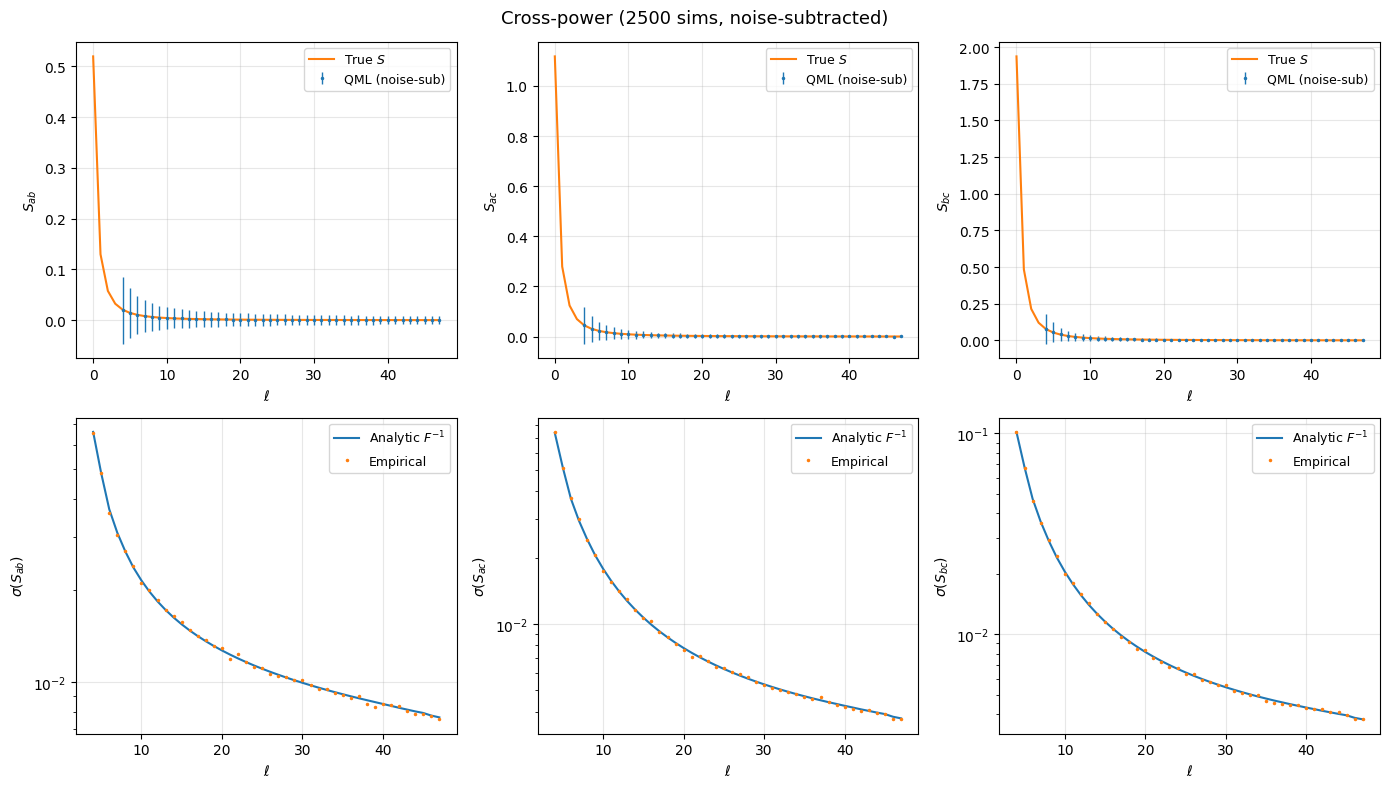

In [30]:
fig, axs = plt.subplots(2, 3, figsize=(14, 8))

cross = [
    ((0,1), S_ab_fid, r'$S_{ab}$'),
    ((0,2), S_ca_fid, r'$S_{ac}$'),
    ((1,2), S_bc_fid, r'$S_{bc}$'),
]

for col, ((fi, fj), S_true, label) in enumerate(cross):
    idx = (f_idx[:,0]==fi) & (f_idx[:,1]==fj)

    axs[0, col].errorbar(ells_plot, e_mean[idx],
                         yerr=np.sqrt(np.diag(err_analytic)[idx]),
                         fmt='.', ms=3, lw=1, label='QML (noise-sub)')
    axs[0, col].plot(ell, S_true, '-', lw=1.5, label='True $S$')
    axs[0, col].set_xlabel(r'$\ell$')
    axs[0, col].set_ylabel(label)
    axs[0, col].legend(fontsize=9)
    axs[0, col].grid(alpha=0.3)

    sig_an = np.sqrt(np.diag(err_analytic)[idx])
    sig_em = np.sqrt(np.diag(err_empirical)[idx])
    axs[1, col].semilogy(ells_plot, sig_an, '-', lw=1.5, label='Analytic $F^{-1}$')
    axs[1, col].semilogy(ells_plot, sig_em, '.', ms=3, label='Empirical')
    axs[1, col].set_xlabel(r'$\ell$')
    axs[1, col].set_ylabel(f'$\sigma$({label})')
    axs[1, col].legend(fontsize=9)
    axs[1, col].grid(alpha=0.3)

plt.suptitle(f'Cross-power ({n_sims} sims, noise-subtracted)', fontsize=13)
plt.tight_layout()
plt.show()

### 8. Errorbar ratio (empirical / analytic)

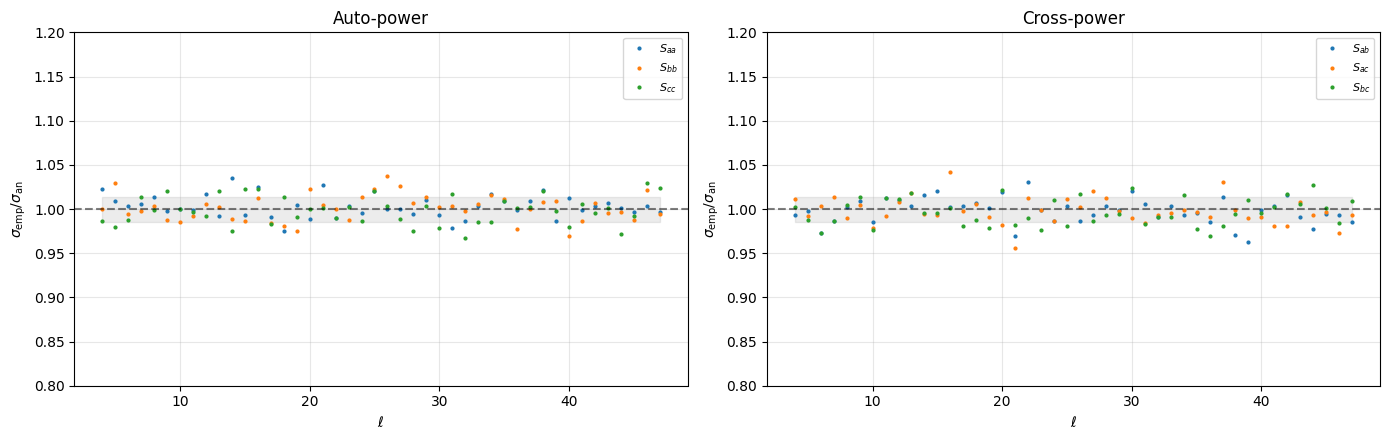

In [31]:
fig, axs = plt.subplots(1, 2, figsize=(14, 4.5))
ratio_err = 1.0 / np.sqrt(2 * (n_sims - 1))

for ax, spec_list, title in [
    (axs[0], spectra, 'Auto-power'),
    (axs[1], cross, 'Cross-power'),
]:
    for (fi, fj), _, label in spec_list:
        idx = (f_idx[:,0]==fi) & (f_idx[:,1]==fj)
        r = np.sqrt(np.diag(err_empirical)[idx]) / np.sqrt(np.diag(err_analytic)[idx])
        ax.plot(ells_plot, r, '.', ms=4, label=label)
    ax.axhline(1.0, color='k', ls='--', alpha=0.5)
    ax.fill_between(ells_plot, 1-ratio_err, 1+ratio_err, alpha=0.15, color='gray')
    ax.set_xlabel(r'$\ell$')
    ax.set_ylabel(r'$\sigma_{\rm emp}/\sigma_{\rm an}$')
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.set_ylim(0.8, 1.2)

plt.tight_layout()
plt.show()